In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import math

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, brier_score_loss
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.utils import resample
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

import xgboost as xgb

from itertools import product

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_seq_items', None)
np.set_printoptions(threshold=np.inf)

# Functions

In [62]:
#Definition of function which produce classification report and confussion matrix for train and also test set 
def class_report(y_train, y_train_pred, y_test, y_test_pred, target_name):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), 
                             gridspec_kw={'height_ratios': [0.5, 1.5]})
    
    #Train classification report
    axes[0, 0].text(-0.2, 0.4, classification_report(y_train, y_train_pred, target_names = target_name), 
                    fontsize=13, family='monospace', va='center')
    axes[0, 0].set_title("Classification Report (Train)", fontsize=14, fontweight='bold')
    axes[0, 0].axis('off') 
    
    #Test classification report
    axes[0, 1].text(-0.2, 0.4, classification_report(y_test, y_test_pred, target_names = target_name), 
                    fontsize=13, family='monospace', va='center')
    axes[0, 1].set_title("Classification Report (Test)", fontsize=14, fontweight='bold')
    axes[0, 1].axis('off') 
    
    # Train Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_train_pred, 
        ax=axes[1, 0], cmap='Blues', normalize='true',
        labels = target_name
    )
    axes[1, 0].set_title("Training Confusion Matrix (Normalized)")
    axes[1, 0].tick_params(axis='x', rotation=90)
    
    # Test Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, 
        ax=axes[1, 1], cmap='Greens', normalize='true',
        labels = target_name
    )
    axes[1, 1].set_title("Testing Confusion Matrix (Normalized)")
    axes[1, 1].tick_params(axis='x', rotation=90)
    
    plt.show()

In [63]:
#Definition of function which produce general calibration curve for train and also test set 
def calibration_curve_general(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    for j, l in zip(range(2), ["train", "test"]):
        ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
        ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")
    
        proba = locals()[f"y_{l}_proba"]
        pred  = locals()[f"y_{l}_pred"]
        true  = locals()[f"y_{l}"]
        
        confidences = np.max(proba, axis=1)
        accuracies = (pred == true).astype(int)
        n_bins = 5
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        bins = np.quantile(confidences, percentiles)
        bin_indices = np.digitize(confidences, bins) - 1
        bin_indices[bin_indices == n_bins] = n_bins - 1
        
        bin_accuracies = []
        bin_confidences = []
        bin_percentages = []
        
        for i in range(n_bins):
            mask = (bin_indices == i)
            if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                bin_accuracies.append(np.mean(accuracies[mask]))
                bin_confidences.append(np.mean(confidences[mask]))
                bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
        ax[j].plot(bin_confidences, bin_accuracies, "bo-", label="Logistic regression")
        
        for b, v, perc in zip(bin_confidences, bin_accuracies, bin_percentages):
            ax[j].annotate(f"{perc:.1f}%", 
                         (b, v), 
                         textcoords="offset points", 
                         xytext=(0, 10), 
                         ha='center',
                         fontsize=10,
                         color="darkblue",
                         fontweight="bold")
        
        ax[j].set_xlabel("Confidence")
        ax[j].set_ylabel("True Accuracy")
        ax[j].set_title(f"Calibration Graph on {l} set")
        ax[j].legend(loc="upper left")
        ax[j].grid(True, alpha=0.5)
        ax[j].set_xlim([-0.05, 1.05])
        ax[j].set_ylim([-0.05, 1.05])
    
    plt.show()

In [64]:
#Definition of function which produce calibration curve per each region for train and also test set 
def calibration_curve_classes(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    for j, a in zip(range(2), ["train", "test"]):
        ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
        ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")
        for l, c in zip(labels, colors):
            proba = locals()[f"y_{a}_proba"]
            pred  = locals()[f"y_{a}_pred"]
            true  = locals()[f"y_{a}"]
        
            subset = (true == l)
            
            confidences = np.max(proba[subset], axis=1)
            accuracies = (pred[subset] == true[subset]).astype(int)
            n_bins = 5
            percentiles = np.linspace(0.0, 1.0, n_bins + 1)
            bins = np.quantile(confidences, percentiles)
            bin_indices = np.digitize(confidences, bins) - 1
            bin_indices[bin_indices == n_bins] = n_bins - 1
            
            bin_accuracies = []
            bin_confidences = []
            bin_percentages = []
            
            for i in range(n_bins):
                mask = (bin_indices == i)
                if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                    bin_accuracies.append(np.mean(accuracies[mask]))
                    bin_confidences.append(np.mean(confidences[mask]))
                    bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
            ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
        
        
        
        ax[j].set_xlabel("Confidence")
        ax[j].set_ylabel("True Accuracy")
        ax[j].set_title(f"Calibration Graph per each class on {a} set")
        ax[j].legend(loc="upper left")
        ax[j].grid(True, alpha=0.5)
        ax[j].set_xlim([-0.05, 1.05])
        ax[j].set_ylim([-0.05, 1.05])
    
    plt.show()

In [65]:
#Definition of function which produce the prediction per one real class for train and also test set 
def predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, region):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['red', 'green', 'blue', 'black']
    for j, a in zip(range(2), ["train", "test"]):
        for l,c in zip(labels, colors):
            proba = locals()[f"y_{a}_proba"]
            pred  = locals()[f"y_{a}_pred"]
            true  = locals()[f"y_{a}"]
        
            subset = (true == region)
            
            confidences = np.max(proba[subset], axis=1)
            accuracies = (pred[subset] == l).astype(int)
            n_bins = 5
            percentiles = np.linspace(0.0, 1.0, n_bins + 1)
            try:
                bins = np.quantile(confidences, percentiles)
                bin_indices = np.digitize(confidences, bins) - 1
                bin_indices[bin_indices == n_bins] = n_bins - 1
                
                bin_accuracies = []
                bin_confidences = []
                bin_percentages = []

                # Výpočet priemernej istoty, presnosti a percenta dát pre každý bin
                for i in range(n_bins):
                    mask = (bin_indices == i)
                    if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                        bin_accuracies.append(np.mean(accuracies[mask]))
                        bin_confidences.append(np.mean(confidences[mask]))
                        bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
            
                # Tvoja krivka modelu
                ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
            except Exception as e:
                continue
            
        
        
        ax[j].set_xlabel("Confidence")
        ax[j].set_ylabel("True Accuracy")
        ax[j].set_title(f"Model Predictions for Actual Central Asia Samples ({a} set)")
        ax[j].legend(loc="upper left")
        ax[j].grid(True, alpha=0.5)
        ax[j].set_xlim([-0.05, 1.05])
        ax[j].set_ylim([-0.05, 1.05])
    
    plt.show()

# Labeled data

In [66]:
data = pd.read_csv("database_from_Bitcointalk.csv")
len(data)

4684

In [67]:
data = data[data["total"]>=15]
print(len(data))
data.columns = data.columns.astype(str)
data.head()

1942


,entity,region,0,1,2,3,4,5,6,7,...,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%
0,Entity 0,Central_Asia,0.025191,0.043089,0.042095,0.049718,0.030162,0.050713,0.034803,0.063971,...,0.014584,0.033477,0.043752,0.036460,2993,8.004032,19,-0.965926,2.588190e-01,0.128273
1,Entity 1,East_Asia_Pac,0.006951,0.020854,0.065541,0.069513,0.077458,0.045680,0.049652,0.060576,...,0.009930,0.006951,0.005958,0.007944,983,6.890609,22,-0.500000,8.660254e-01,0.037736
2,Entity 10,Euro_Africa,0.064461,0.054147,0.052858,0.033090,0.026214,0.027503,0.018049,0.015900,...,0.061453,0.055866,0.067039,0.066609,2303,7.741968,8,0.866025,-5.000000e-01,0.091104
3,Entity 100,East_Asia_Pac,0.008368,0.020921,0.029289,0.025105,0.029289,0.071130,0.025105,0.062762,...,0.025105,0.008368,0.020921,0.008368,215,5.370638,23,-0.258819,9.659258e-01,0.066946
4,Entity 1000,Euro_Africa,0.035714,0.107143,0.107143,0.053571,0.053571,0.017857,0.035714,0.053571,...,0.017857,0.035714,0.035714,0.017857,32,3.465736,18,-1.000000,-1.836970e-16,0.107143


In [68]:
X = data
y = data["region"]
col_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]

# Data unlabeled

In [69]:
data_unlabeled = pd.read_csv("database_from_Bitcointalk_not_labeled.csv")
len(data_unlabeled)

16236

In [70]:
data_unlabeled = data_unlabeled[data_unlabeled["total"]>=15]
print(len(data_unlabeled))
data_unlabeled.columns = data_unlabeled.columns.astype(str)
data_unlabeled.head()

10885


,entity,0,1,2,3,4,5,6,7,8,...,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%
1,Entity 10001,0.005236,0.020942,0.015707,0.015707,0.031414,0.052356,0.036649,0.041885,0.031414,...,0.010471,0.005236,0.026178,0.010471,167,5.117994,22,-0.500000,0.866025,0.057592
2,Entity 10002,0.021739,0.021739,0.021739,0.021739,0.021739,0.065217,0.086957,0.021739,0.021739,...,0.021739,0.021739,0.021739,0.021739,22,3.091042,2,0.500000,0.866025,0.108696
5,Entity 10006,0.018868,0.103774,0.037736,0.009434,0.056604,0.066038,0.028302,0.047170,0.122642,...,0.009434,0.018868,0.037736,0.037736,82,4.406719,22,-0.500000,0.866025,0.122642
6,Entity 10007,0.003676,0.003676,0.003676,0.003676,0.003676,0.003676,0.003676,0.003676,0.011029,...,0.022059,0.018382,0.003676,0.003676,248,5.513429,2,0.500000,0.866025,0.018382
7,Entity 10010,0.009009,0.063063,0.009009,0.054054,0.009009,0.045045,0.009009,0.054054,0.108108,...,0.009009,0.036036,0.009009,0.009009,87,4.465908,20,-0.866025,0.500000,0.072072


In [71]:
data_unlabeled = data_unlabeled.drop_duplicates(subset = col_names, keep = "first")
len(data_unlabeled)

9837

In [72]:
X_unlabeled = data_unlabeled
len(X_unlabeled)

9837

# Self-learning

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = 7736)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
labels = le.classes_

In [20]:
X_L = X_train[col_names]
y_L = y_train_encoded
X_U = X_unlabeled[col_names]
y_U = np.full(shape=X_U.shape[0], fill_value=-1)

In [21]:
class ManualSelfTraining(BaseEstimator, ClassifierMixin):
    def __init__(self, base_model, conf=0.8, max_iter=10, prt = False):
        self.base_model = base_model
        self.conf = conf
        self.prt = prt
        self.max_iter = max_iter
        
        self.history_ = []

    def fit(self, X, y, X_U): 
        X_L = X.copy()
        y_L = y.copy()
        X_unlabeled = X_U.copy()
        
        # Sem vlož tvoju logiku cyklu (tú funkciu, čo si napísal)
        for i in range(self.max_iter):
            sample_weights = compute_sample_weight(class_weight='balanced', y=y_L)
            self.base_model.fit(X_L, y_L, sample_weight=sample_weights)
            
            if len(X_unlabeled) == 0:
                if self.prt:
                    print(f"Iteration {i}: No more unlabeled data. Finishing.")
                break
            
            y_U_proba = self.base_model.predict_proba(X_unlabeled)
            y_U_pred = self.base_model.predict(X_unlabeled)
            
            confidences = np.max(y_U_proba, axis=1)
            index = confidences >= self.conf
            
            X_pseudo = X_unlabeled[index].copy()
            y_pseudo = y_U_pred[index]
            
            if self.prt:
                print(f"Iteration {i} labeled {len(y_pseudo)} samples out of {len(X_unlabeled)} samples.")

            if len(y_pseudo) == 0:
                if self.prt:
                    print("Zero samples labeled. Stopping.")
                break
            
            X_L = pd.concat([X_L, X_pseudo]).reset_index(drop=True)
            y_L = np.concatenate([y_L, y_pseudo])

            X_unlabeled = X_unlabeled[~index]
            self.history_.append(len(y_pseudo))
        self.final_model_ = self.base_model
        if self.prt:
            print("-" * 50)
            print(f"Training finished. Final L size: {len(X_L)}")
        return self

    def predict(self, X):
        return self.base_model.predict(X)
    
    def predict_proba(self, X):
        return self.base_model.predict_proba(X)

In [22]:
def custom_stratified_cv(conf, max_iter, X_L, y_L, X_U, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    quality_metrics = pd.DataFrame(columns = ["f1_train", "f1_test", "brier_train", "brier_test"])
    

    for i, (train_idx, val_idx) in enumerate(skf.split(X_L, y_L),1):
        X_train_f, y_train_f = X_L.iloc[train_idx], y_L[train_idx]
        X_val_f, y_val_f = X_L.iloc[val_idx], y_L[val_idx]
        
        base_model = xgb.XGBClassifier(
            n_estimators= 211,              
            eta= 0.038741570723655985,
            gamma = 4.998847340927335,
            reg_lambda =3.316876517397734,
            max_depth = 2,
            min_child_weight= 19,           
            subsample =0.63506725808971654,
            colsample_bytree=0.8466734018456014
        )
        model = ManualSelfTraining(
            base_model= base_model,
            conf=conf,
            max_iter=max_iter,
            prt=True
        )
        
        model.fit(X_train_f, y_train_f, X_U=X_U)
        
        y_train_pred = model.predict(X_train_f)
        y_train_proba = model.predict_proba(X_train_f)
        
        y_test_pred = model.predict(X_val_f)
        y_test_proba = model.predict_proba(X_val_f)

        quality_metrics.loc[i, "f1_train"] = f1_score(y_train_f, y_train_pred, average = "weighted")
        quality_metrics.loc[i, "f1_test"] = f1_score(y_val_f, y_test_pred, average = "weighted")
        quality_metrics.loc[i, "brier_train"] = -brier_score_loss(y_train_f, y_train_proba)
        quality_metrics.loc[i, "brier_test"] = -brier_score_loss(y_val_f, y_test_proba)
        
        
    
    f1_test = np.mean(quality_metrics["f1_test"])
    f1_train = np.mean(quality_metrics["f1_train"])
    brier_test = np.mean(quality_metrics["brier_test"])
    brier_train = np.mean(quality_metrics["brier_train"])
    
    return f1_test, f1_train, brier_test, brier_train

In [23]:
X_L = X_train[col_names]
y_L = y_train_encoded
X_U = X_unlabeled[col_names]
y_U = np.full(shape=X_U.shape[0], fill_value=-1)
f1_test, f1_train, brier_test, brier_train = custom_stratified_cv(0.90, 10, X_L, y_L, X_U, n_splits=5)
print(f"F1_train: {f1_train:.4f}, F1_test: {f1_test:.4f}, Brier_train: {brier_train:.4f}, Brier_test: {brier_test:.4f}")

Iteration 0 labeled 15 samples out of 9837 samples.
Iteration 1 labeled 1 samples out of 9822 samples.
Iteration 2 labeled 1 samples out of 9821 samples.
Iteration 3 labeled 0 samples out of 9820 samples.
Zero samples labeled. Stopping.
--------------------------------------------------
Training finished. Final L size: 1181
Iteration 0 labeled 15 samples out of 9837 samples.
Iteration 1 labeled 3 samples out of 9822 samples.
Iteration 2 labeled 2 samples out of 9819 samples.
Iteration 3 labeled 0 samples out of 9817 samples.
Zero samples labeled. Stopping.
--------------------------------------------------
Training finished. Final L size: 1185
Iteration 0 labeled 6 samples out of 9837 samples.
Iteration 1 labeled 2 samples out of 9831 samples.
Iteration 2 labeled 1 samples out of 9829 samples.
Iteration 3 labeled 1 samples out of 9828 samples.
Iteration 4 labeled 0 samples out of 9827 samples.
Zero samples labeled. Stopping.
--------------------------------------------------
Training f

## Model

In [25]:
base_model = xgb.XGBClassifier(
    n_estimators= 211,              
    eta= 0.038741570723655985,
    gamma = 4.998847340927335,
    reg_lambda =3.316876517397734,
    max_depth = 2,
    min_child_weight= 19,           
    subsample =0.63506725808971654,
    colsample_bytree=0.8466734018456014
)
model = ManualSelfTraining(base_model= base_model, conf=0.90, max_iter=10, prt = True)
X_L = X_train[col_names]
y_L = y_train_encoded
X_U = X_unlabeled[col_names]
y_U = np.full(shape=X_U.shape[0], fill_value=-1)
model.fit(
    X=X_L, 
    y=y_L, 
    X_U=X_U
)

Iteration 0 labeled 20 samples out of 9837 samples.
Iteration 1 labeled 3 samples out of 9817 samples.
Iteration 2 labeled 2 samples out of 9814 samples.
Iteration 3 labeled 0 samples out of 9812 samples.
Zero samples labeled. Stopping.
--------------------------------------------------
Training finished. Final L size: 1481


,base_model,"XGBClassifier...obs=None, ...)"
,conf,0.9
,max_iter,10
,prt,True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8466734018456014


In [28]:
y_train_pred = model.predict(X_train[col_names])
y_train_pred = le.inverse_transform(y_train_pred)
y_train_proba = model.predict_proba(X_train[col_names])

y_test_pred = model.predict(X_test[col_names])
y_test_pred = le.inverse_transform(y_test_pred)
y_test_proba = model.predict_proba(X_test[col_names])

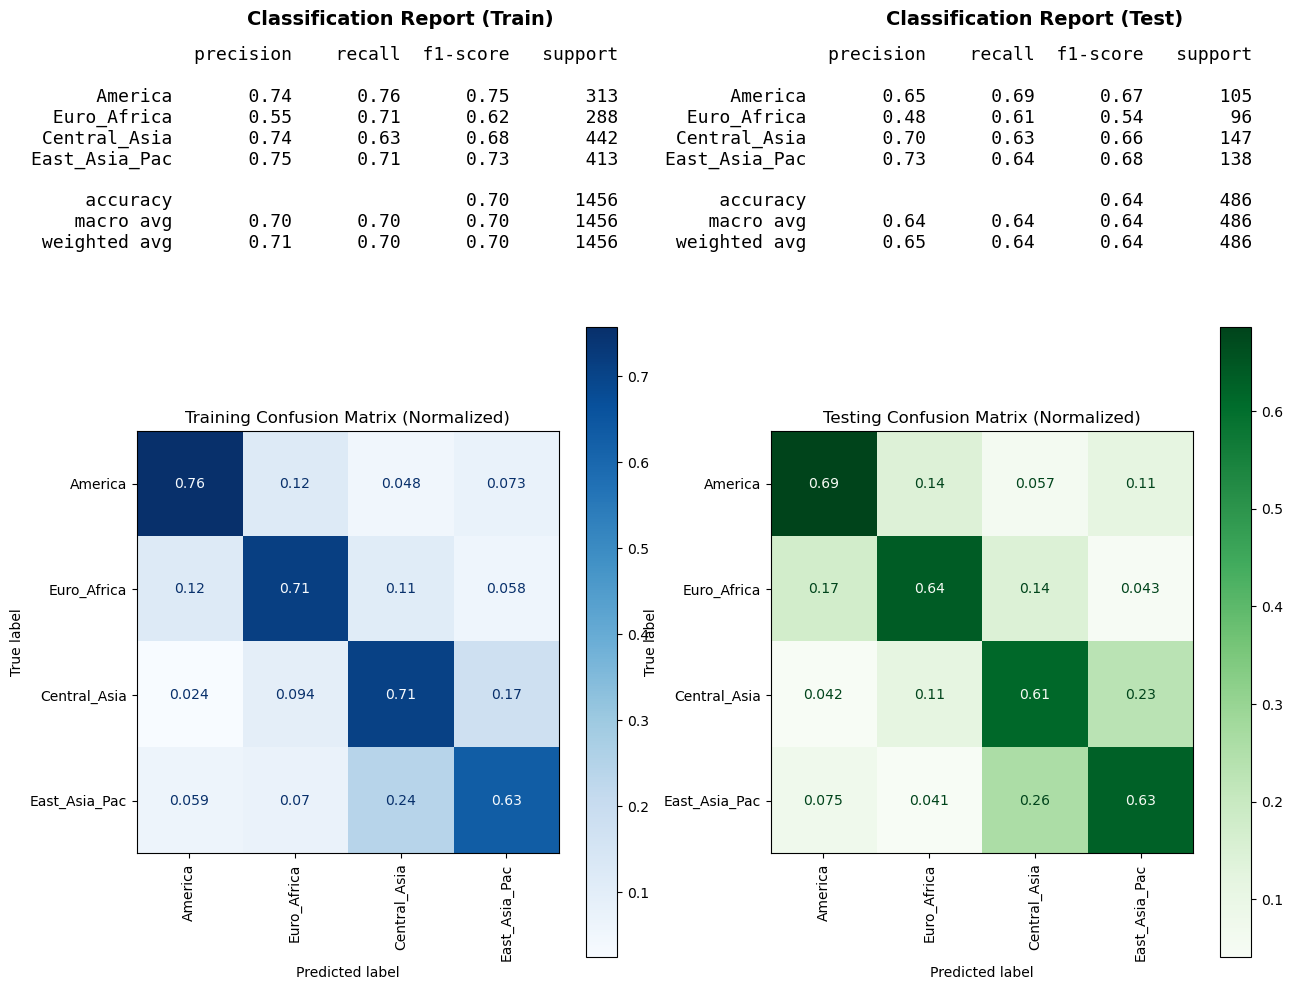

In [29]:
target_names = ["America", "Euro_Africa", "Central_Asia", "East_Asia_Pac"]
class_report(y_train, y_train_pred, y_test, y_test_pred, target_names)

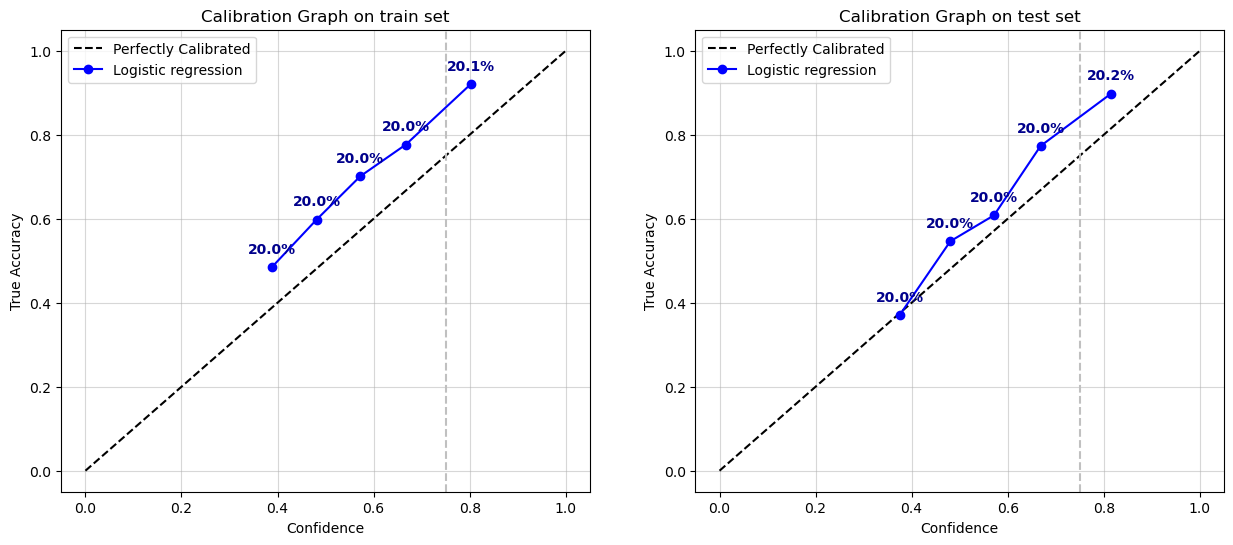

In [30]:
calibration_curve_general(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred)

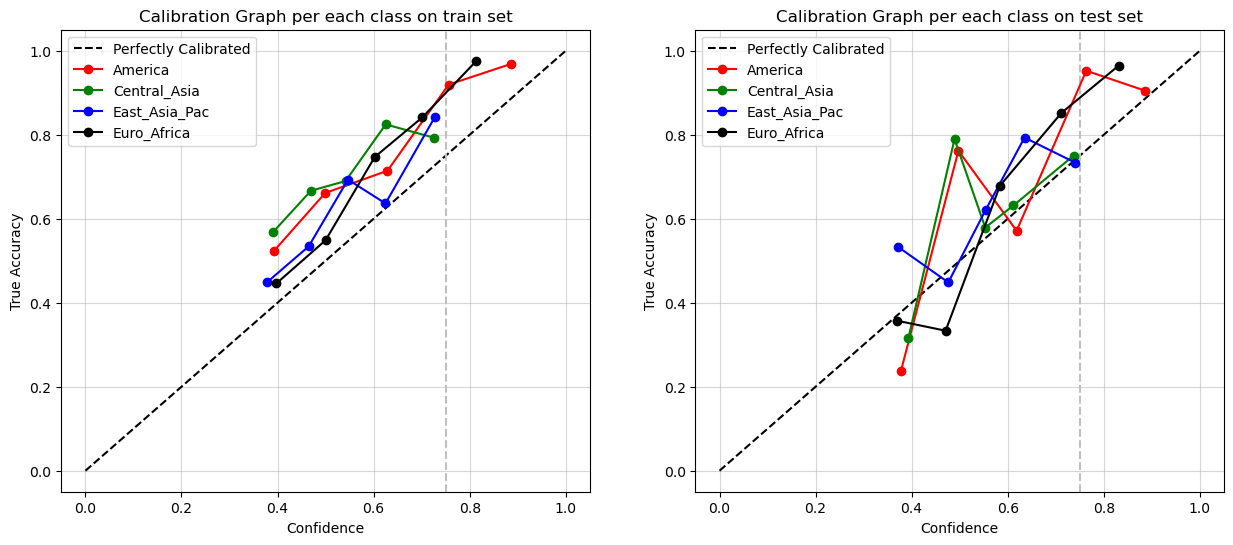

In [31]:
colors = ['red', 'green', 'blue', 'black']
calibration_curve_classes(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels)

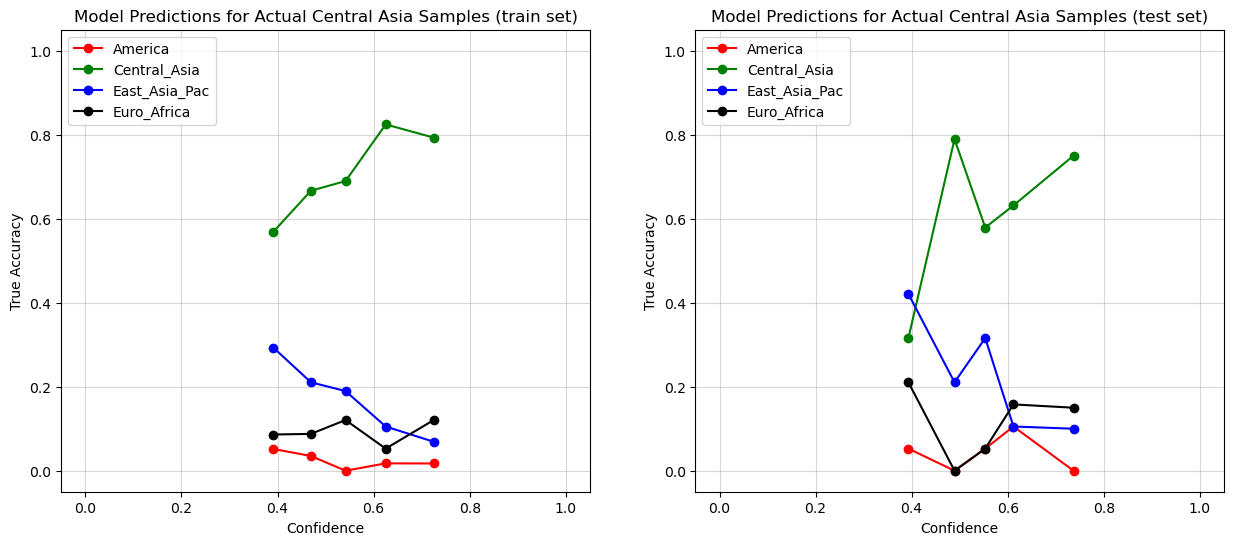

In [32]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "Central_Asia")

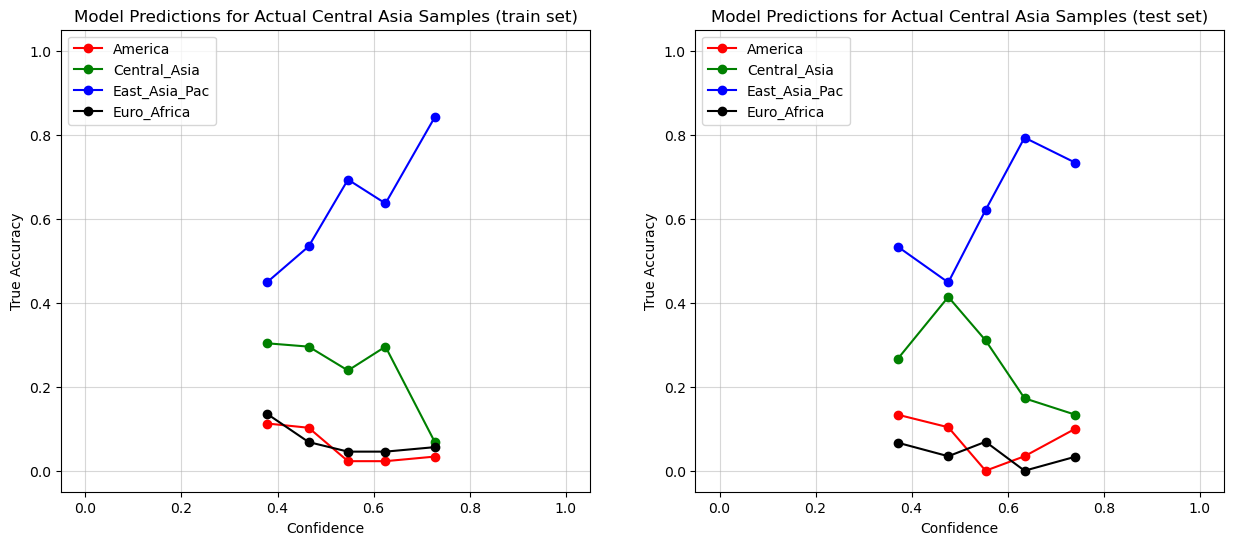

In [33]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "East_Asia_Pac")

# Label Propagation

In [73]:
X_unlabeled = data_unlabeled
len(X_unlabeled)

9837

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = 7736)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[col_names])
X_unlabeled_scaled = scaler.transform(X_unlabeled[col_names])

In [75]:
X_mixed = np.concatenate([X_train_scaled, X_unlabeled_scaled])

In [76]:
y_unlabeled = np.full(X_unlabeled.shape[0], -1)
y_mixed = np.concatenate([y_train_encoded, y_unlabeled])

In [77]:
lp_model = LabelPropagation(kernel='knn',  n_neighbors = 10,  max_iter=10000)
lp_model.fit(X_mixed, y_mixed)

,kernel,'knn'
,gamma,20
,n_neighbors,10
,max_iter,10000
,tol,0.001
,n_jobs,None


In [78]:
lp_predictions = lp_model.transduction_[len(X_train):]
lp_probs = lp_model.label_distributions_[len(X_train):]
lp_max_probs = np.max(lp_probs, axis=1)

In [79]:
predicted_names = le.inverse_transform(lp_predictions)
results_df = X_unlabeled.copy()
results_df['predicted_y'] = predicted_names
results_df[labels] = lp_probs
results_df.head()

,entity,0,1,2,3,4,5,6,7,8,...,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%,predicted_y,America,Central_Asia,East_Asia_Pac,Euro_Africa
1,Entity 10001,0.005236,0.020942,0.015707,0.015707,0.031414,0.052356,0.036649,0.041885,0.031414,...,5.117994,22,-0.500000,0.866025,0.057592,Central_Asia,0.062149,0.480519,0.375560,0.081771
2,Entity 10002,0.021739,0.021739,0.021739,0.021739,0.021739,0.065217,0.086957,0.021739,0.021739,...,3.091042,2,0.500000,0.866025,0.108696,East_Asia_Pac,0.223247,0.164974,0.511554,0.100226
5,Entity 10006,0.018868,0.103774,0.037736,0.009434,0.056604,0.066038,0.028302,0.047170,0.122642,...,4.406719,22,-0.500000,0.866025,0.122642,East_Asia_Pac,0.097757,0.102547,0.721370,0.078326
6,Entity 10007,0.003676,0.003676,0.003676,0.003676,0.003676,0.003676,0.003676,0.003676,0.011029,...,5.513429,2,0.500000,0.866025,0.018382,Euro_Africa,0.052760,0.386415,0.157053,0.403772
7,Entity 10010,0.009009,0.063063,0.009009,0.054054,0.009009,0.045045,0.009009,0.054054,0.108108,...,4.465908,20,-0.866025,0.500000,0.072072,East_Asia_Pac,0.038695,0.162564,0.498406,0.300336


In [80]:
results_df.to_excel("test.xlsx")

In [81]:
confidences = np.max(lp_probs, axis = 1)
index = (confidences >= 0.85)
sum(index)

np.int64(271)

In [91]:
X_L_new = X_unlabeled[index]
y_L_new = le.transform(predicted_names[index])
len(X_L_new)

271

In [83]:
X_train_new = pd.concat([X_train, X_L_new])[col_names]
y_train_new = np.concatenate([y_train_encoded, y_L_new])
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_new)

## Parameters fitting

In [46]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "eta": trial.suggest_float("eta", 0.01, 0.1),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = xgb.XGBClassifier(
        **param,
    )


    scoring = {
        'brier': 'neg_brier_score',
        'wf1': 'f1_weighted'
    }
    
    cv_results = cross_validate(model, X_train_new, y_train_new, params={'sample_weight': sample_weights}, cv = 5, scoring=scoring, return_train_score = True)
    brier_test =  cv_results['test_brier'].mean()
    brier_train = cv_results["train_brier"].mean()
    f1_train = cv_results['train_wf1'].mean()
    f1_test = cv_results['test_wf1'].mean()

    trial.set_user_attr("brier_test", brier_test)
    trial.set_user_attr("brier_train", brier_train)
    trial.set_user_attr("f1_train", f1_train)
    trial.set_user_attr("f1_test", f1_test)
    
    
    score = brier_test - 1 * (brier_train-brier_test)
    return score

In [48]:
study = optuna.create_study(study_name = "xgboost_study", direction = "maximize")
study.optimize(objective, n_trials = 100, show_progress_bar = True, n_jobs = 1)

[I 2026-04-30 14:26:23,859] A new study created in memory with name: xgboost_study


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-30 14:26:28,431] Trial 0 finished with value: -0.5479285733673982 and parameters: {'n_estimators': 813, 'eta': 0.09817843066624396, 'gamma': 2.9278050034829284, 'reg_lambda': 2.9572433430924665, 'max_depth': 2, 'min_child_weight': 20, 'subsample': 0.8233632430706961, 'colsample_bytree': 0.6018422812607795}. Best is trial 0 with value: -0.5479285733673982.
[I 2026-04-30 14:26:30,124] Trial 1 finished with value: -0.6494994407792138 and parameters: {'n_estimators': 106, 'eta': 0.08153072012043454, 'gamma': 1.7826600312862833, 'reg_lambda': 3.432880506124592, 'max_depth': 8, 'min_child_weight': 4, 'subsample': 0.7224337849519595, 'colsample_bytree': 0.8216775325785399}. Best is trial 0 with value: -0.5479285733673982.
[I 2026-04-30 14:26:34,768] Trial 2 finished with value: -0.5399180611371578 and parameters: {'n_estimators': 745, 'eta': 0.05768928327704622, 'gamma': 4.30563673022135, 'reg_lambda': 4.235640679901465, 'max_depth': 4, 'min_child_weight': 13, 'subsample': 0.646316

In [49]:
best_params = study.best_params
best_params

{'n_estimators': 609,
 'eta': 0.011670606068335362,
 'gamma': 4.847840582330452,
 'reg_lambda': 4.488324645977471,
 'max_depth': 2,
 'min_child_weight': 19,
 'subsample': 0.6234573888944965,
 'colsample_bytree': 0.6951655006545885}

In [50]:
df = study.trials_dataframe()
print(df[['value', 'user_attrs_brier_train', 'user_attrs_brier_test', 'user_attrs_f1_train', 'user_attrs_f1_test']])

       value  user_attrs_brier_train  user_attrs_brier_test  \
0  -0.547929               -0.348703              -0.448316   
1  -0.649499               -0.231133              -0.440316   
2  -0.539918               -0.358308              -0.449113   
3  -0.555564               -0.347113              -0.451338   
4  -0.652475               -0.230470              -0.441472   
5  -0.575688               -0.307696              -0.441692   
6  -0.553140               -0.345410              -0.449275   
7  -0.584897               -0.309137              -0.447017   
8  -0.698115               -0.182238              -0.440176   
9  -0.717712               -0.166079              -0.441896   
10 -0.528755               -0.380215              -0.454485   
11 -0.527497               -0.381781              -0.454639   
12 -0.529246               -0.381870              -0.455558   
13 -0.530082               -0.378847              -0.454464   
14 -0.544635               -0.347332              -0.44

## Model

In [84]:
X_train_new = pd.concat([X_train, X_L_new])[col_names]
y_train_new = np.concatenate([y_train_encoded, y_L_new])
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_new)
model = xgb.XGBClassifier(
    n_estimators= 609,              
    eta= 0.011670606068335362,
    gamma = 4.847840582330452,
    reg_lambda =4.488324645977471,
    max_depth = 2,
    min_child_weight= 19,           
    subsample =0.6234573888944965,
    colsample_bytree= 0.6951655006545885
)

model.fit(X_train_new, y_train_new, sample_weight = sample_weights)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6951655006545885
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [85]:
y_train = le.inverse_transform(y_train_new)
y_train_pred = model.predict(X_train_new)
y_train_pred = le.inverse_transform(y_train_pred)
y_train_proba = model.predict_proba(X_train_new)

y_test_pred = model.predict(X_test[col_names])
y_test_pred = le.inverse_transform(y_test_pred)
y_test_proba = model.predict_proba(X_test[col_names])

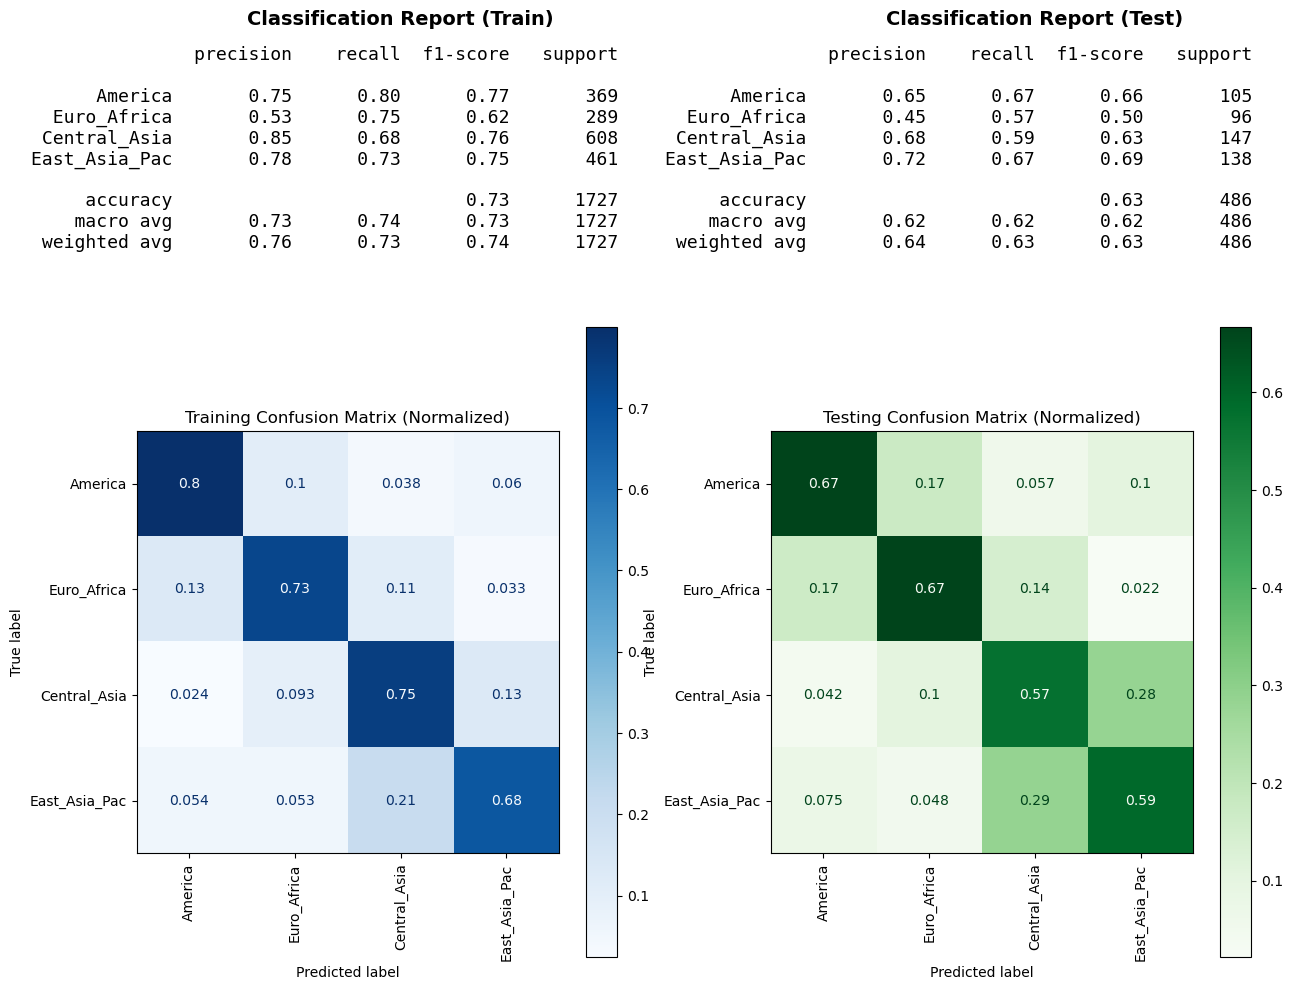

In [86]:
class_report(y_train, y_train_pred, y_test, y_test_pred, target_names)

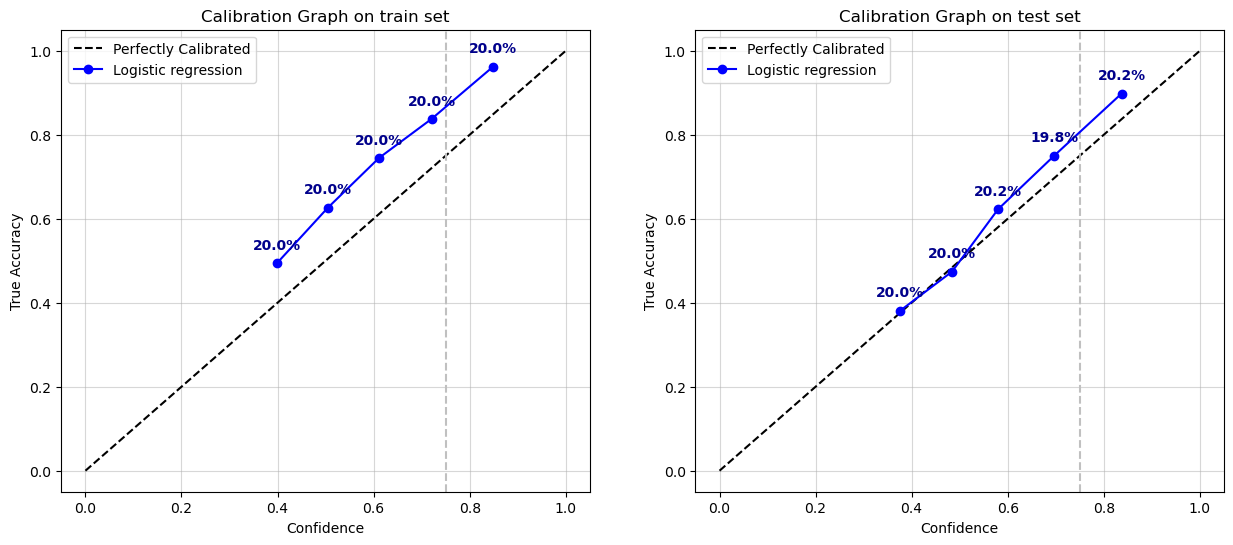

In [87]:
calibration_curve_general(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred)

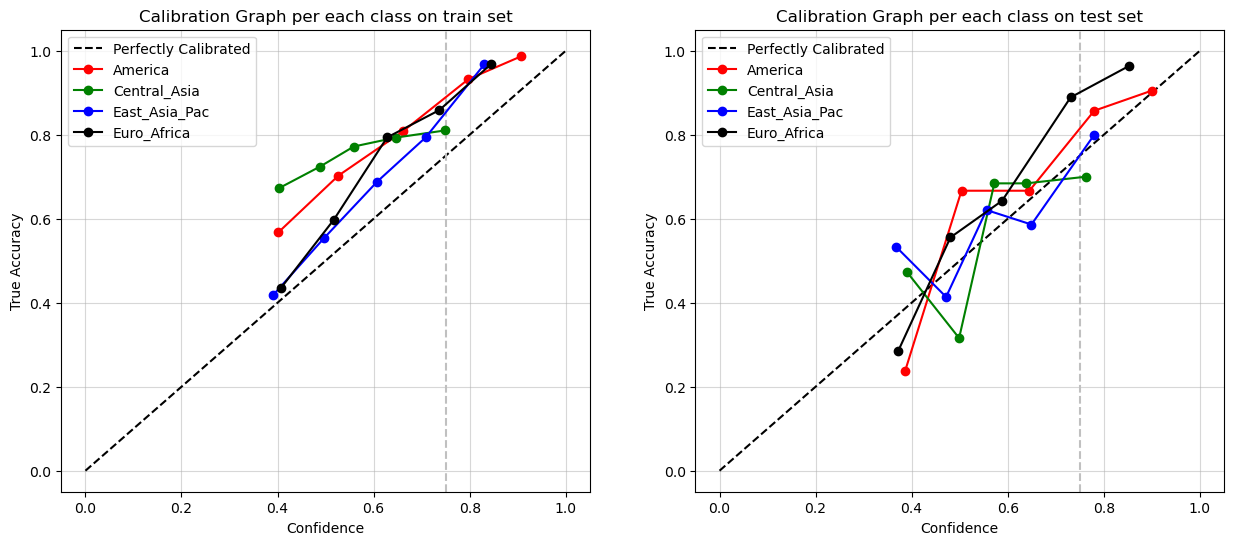

In [88]:
colors = ['red', 'green', 'blue', 'black']
calibration_curve_classes(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels)

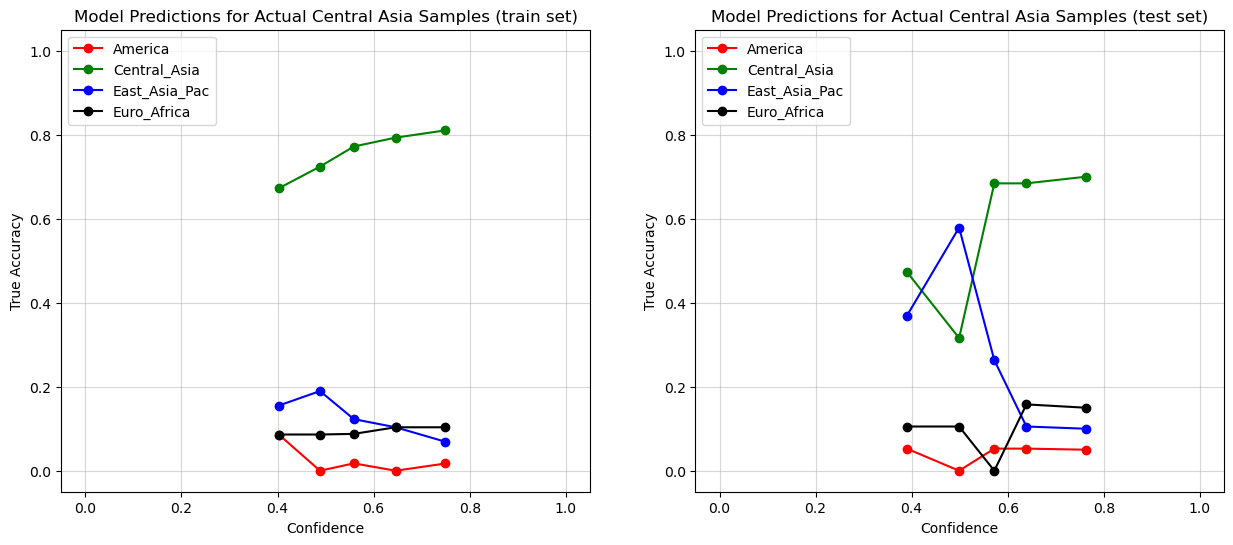

In [89]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "Central_Asia")

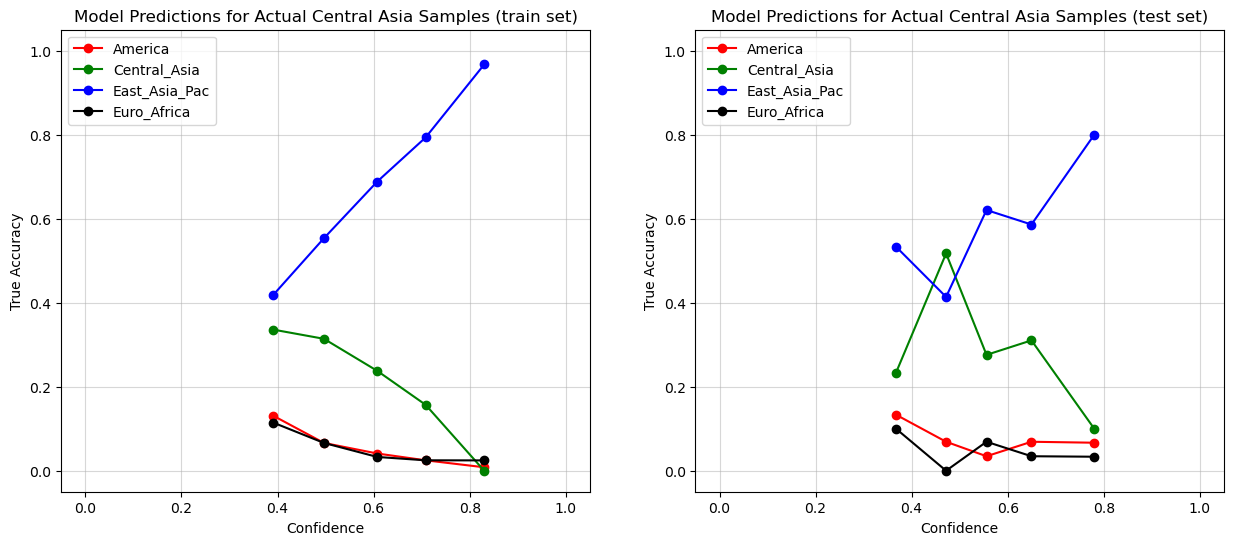

In [90]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "East_Asia_Pac")